# 00. 연습: 가짜 기계 소리로 파이프라인 미리 체험하기

MIMII 데이터 다운로드를 기다리는 동안, 코드로 직접 만든 가짜 소리로 연습한다.

- **정상 소리**: 일정한 웅웅거림 (기계가 규칙적으로 도는 소리)
- **이상 소리**: 웅웅거림 + 불규칙한 '탁탁' 충격음 (부품이 헐거워진 상황 가정)

이걸 파형과 스펙트로그램으로 그려보면서 "소리를 이미지로 바꿔서 비교한다"는
이 프로젝트의 핵심 개념을 눈으로 확인한다.

> 커널은 **DL_PY311** 을 선택할 것 (torch, librosa 설치되어 있는 환경)

In [1]:
import numpy as np
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt
import koreanize_matplotlib

## 1. 정상 소리 만들기

소리 = 시간에 따라 진동하는 숫자의 배열이다.
기계의 웅웅거림은 사인파(일정하게 반복되는 파동) 몇 개를 더해서 흉내낼 수 있다.

In [2]:
sr = 16000          # 샘플링 레이트: 1초를 16000개의 숫자로 표현 (MIMII와 동일)
duration = 3        # 3초짜리 소리

t = np.arange(sr * duration) / sr   # 시간축 (0초 ~ 3초)

# 기계 회전음: 120Hz 기본음 + 배음(240, 360Hz)을 섞는다
normal = 0.5 * np.sin(2 * np.pi * 120 * t)
normal = normal + 0.2 * np.sin(2 * np.pi * 240 * t)
normal = normal + 0.1 * np.sin(2 * np.pi * 360 * t)

# 실제 기계처럼 약간의 잡음 추가
normal = normal + 0.05 * np.random.randn(len(t))

print('데이터 개수 :', len(normal))
print('앞 5개 값   :', normal[:5])

데이터 개수 : 48000
앞 5개 값   : [0.0511539  0.05967177 0.20825455 0.18026728 0.20009333]


## 2. 이상 소리 만들기

정상 소리에 불규칙한 '탁탁' 충격음을 랜덤한 시점에 심는다.
(베어링 마모, 부품 헐거움 같은 고장의 소리 특징)

In [ ]:
abnormal = normal.copy()

np.random.seed(0)
click_times = np.random.randint(0, len(t) - 800, size=8)   # 충격음 8번, 랜덤 위치

for start in click_times:
    # 짧고 강한 진동(충격음)을 만들어서 그 위치에 더한다
    click = 0.9 * np.sin(2 * np.pi * 3000 * t[:800]) * np.exp(-t[:800] * 80)
    abnormal[start:start + 800] = abnormal[start:start + 800] + click

print('충격음이 심어진 위치(초):', np.sort(click_times) / sr)

충격음이 심어진 위치(초): [0.17075   1.3276875 1.9001875 2.0064375 2.6245625 2.6633125 2.7229375
 2.8681875]


## 3. wav 파일로 저장하고 직접 들어보기

저장된 파일을 탐색기에서 더블클릭해서 귀로 차이를 들어보자.

In [4]:
import os
os.makedirs('../data/practice', exist_ok=True)

sf.write('../data/practice/normal.wav', normal, sr)
sf.write('../data/practice/abnormal.wav', abnormal, sr)
print('저장 완료: data/practice 폴더 확인')

저장 완료: data/practice 폴더 확인


## 4. 파형 비교 (시간에 따른 소리 크기)

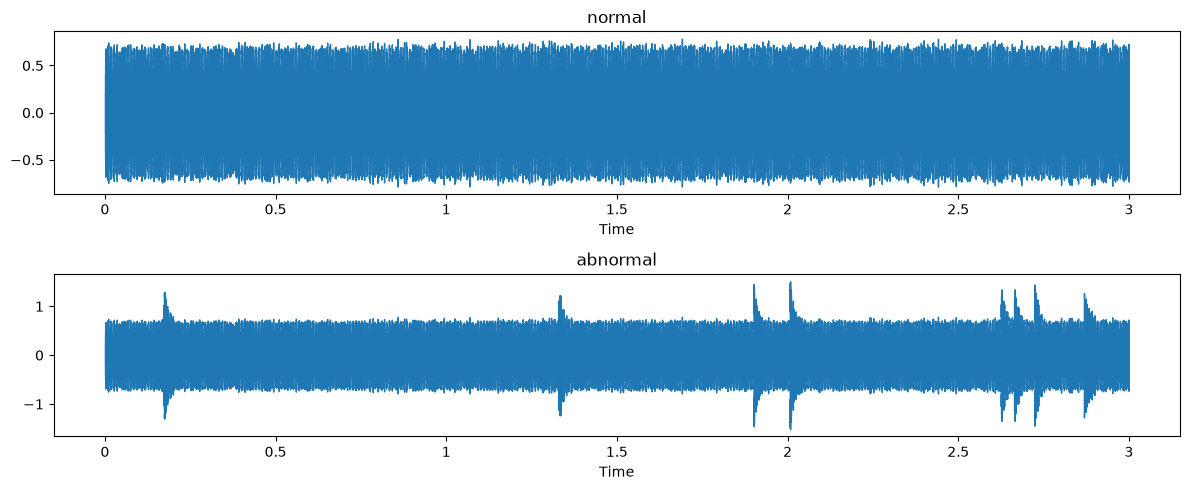

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(2, 1, 1)
librosa.display.waveshow(normal, sr=sr)
plt.title('정상')

plt.subplot(2, 1, 2)
librosa.display.waveshow(abnormal, sr=sr)
plt.title('이상')

plt.tight_layout()
plt.show()

## 5. 멜 스펙트로그램 비교 (소리를 이미지로)

- 가로축 = 시간, 세로축 = 주파수(음높이), 색 = 그 소리 성분의 세기
- 이 "이미지"가 나중에 CNN/AutoEncoder의 입력이 된다

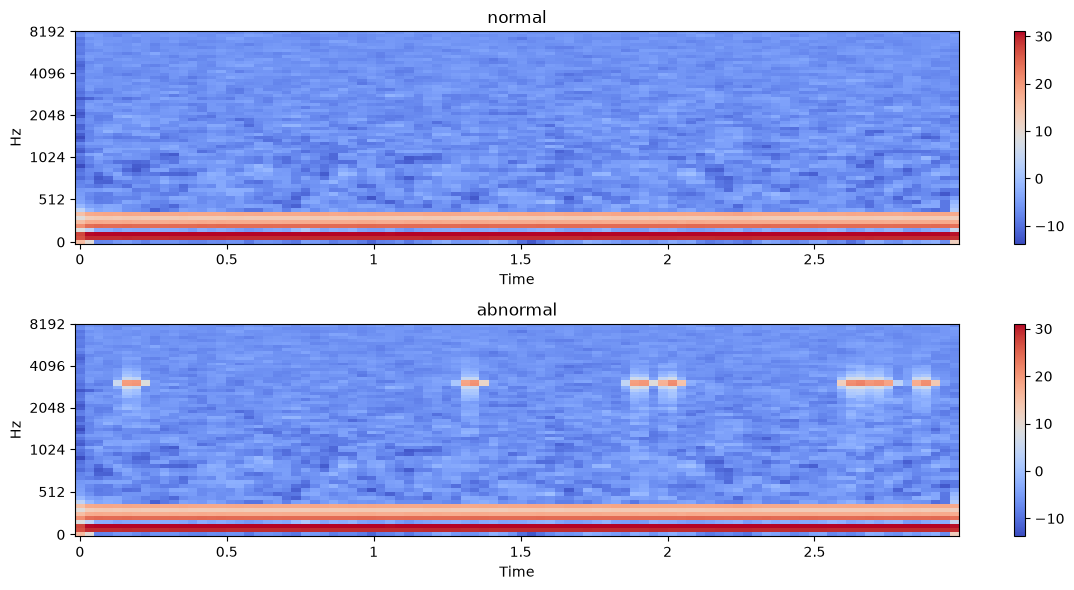

In [6]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
mel = librosa.feature.melspectrogram(y=normal, sr=sr, n_mels=64)
librosa.display.specshow(librosa.power_to_db(mel), sr=sr, x_axis='time', y_axis='mel')
plt.colorbar()
plt.title('정상')

plt.subplot(2, 1, 2)
mel = librosa.feature.melspectrogram(y=abnormal, sr=sr, n_mels=64)
librosa.display.specshow(librosa.power_to_db(mel), sr=sr, x_axis='time', y_axis='mel')
plt.colorbar()
plt.title('이상')

plt.tight_layout()
plt.show()

## 관찰 포인트

1. 파형에서 이상 소리의 충격음이 어디에 보이는가? (2번 셀에서 출력한 위치와 비교)
2. 스펙트로그램에서 정상은 가로줄(일정한 음)만 있는데, 이상은 무엇이 추가로 보이는가?
3. 만약 배경 소음이 심해지면(잡음 0.05 -> 0.5로 바꿔서 재실행) 충격음이 여전히 잘 보일까?

3번이 바로 MIMII의 6dB / 0dB / -6dB 실험과 같은 질문이다.

실제 데이터가 다운로드되면 01 노트북에서 진짜 기계 소리로 같은 과정을 반복한다.